<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 15 - Ejemplo 2 - KNN
        </td>
    </tr>
    <tr>
 

</table>

In [3]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

Se utilizará el conjunto de datos Iris, disponible en la librería `sklearn.datasets`, el cual contiene mediciones de flores pertenecientes a tres especies diferentes. El objetivo del problema es construir un modelo de clasificación supervisada que permita predecir la especie de una flor a partir de sus características morfológicas.



El dataset contiene las siguientes variables predictoras:

| Variable | Descripción |
|---|---|
| `sepal length (cm)` | Longitud del sépalo en centímetros |
| `sepal width (cm)` | Ancho del sépalo en centímetros |
| `petal length (cm)` | Longitud del pétalo en centímetros |
| `petal width (cm)` | Ancho del pétalo en centímetros |

La variable respuesta corresponde a la especie de la flor, clasificada en tres categorías:

| Clase | Especie |
|---|---|
| `0` | Setosa |
| `1` | Versicolor |
| `2` | Virginica |

1) Representar en un diagrama de dispersión las variables longitud del sépalo y ancho del sépalo.
2) Aplicar el método de KNN con $k=10$ y luego con $k=20$ analizando cada de sus métricas.
3) Utilizar validación cruzada para determinar el valor de $k$ óptimo que maximice el accuracy score
4) Crear el modelo de KNN con el valor de $k$ óptimo para clasificar a una persona tomando la media de ambas variables predictoras.

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["Tipo"] = iris.target 

In [5]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Tipo
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Tipo               150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Tipo
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


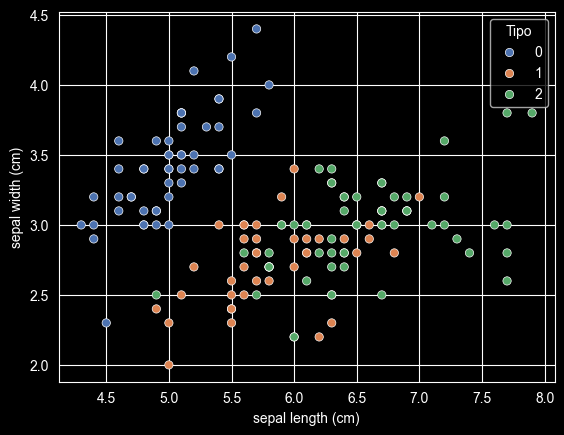

In [8]:
#1) Crear gráfico de dispersión 
plt.figure()
sns.scatterplot(data=iris_df, x="sepal length (cm)", y="sepal width (cm)", hue="Tipo", palette="deep")
plt.show()

In [9]:
X_independientes = iris_df[["sepal length (cm)", "sepal width (cm)"]]
y_dependiente = iris_df["Tipo"]

In [10]:
from sklearn.preprocessing import StandardScaler

escalar = StandardScaler()
escalar.fit(X_independientes)

X_independientes_tr = escalar.transform(X_independientes)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN_10 = KNeighborsClassifier(n_neighbors =10)
model_KNN_10.fit(X_independientes_tr, y_dependiente)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


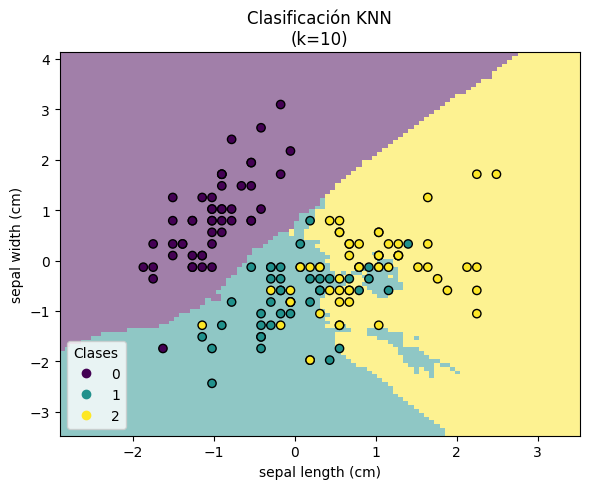

In [33]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

weights = "uniform"

model_KNN_10.set_params(weights=weights).fit(X_independientes_tr, y_dependiente)

disp = DecisionBoundaryDisplay.from_estimator(
    model_KNN_10,
    X_independientes_tr,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel="sepal length (cm)",
    ylabel="sepal width (cm)",
    shading="auto",
    alpha=0.5,
    ax=ax,
)

scatter = disp.ax_.scatter(
    X_independientes_tr[:, 0],
    X_independientes_tr[:, 1],c=y_dependiente, edgecolors="k"
)

disp.ax_.legend(
    scatter.legend_elements()[0],
    y_dependiente.unique(),
    loc="lower left",
    title="Clases",
)

disp.ax_.set_title(
    f"Clasificación KNN\n(k={model_KNN_10.n_neighbors})"
)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_10 = model_KNN_10.predict(X_independientes_tr)
accuracy_10 = accuracy_score(y_dependiente, y_pred_10)
print("El accuracy score que se tiene es %s" %accuracy_10)

El accuracy score que se tiene es 0.84


Text(50.722222222222214, 0.5, 'Real')

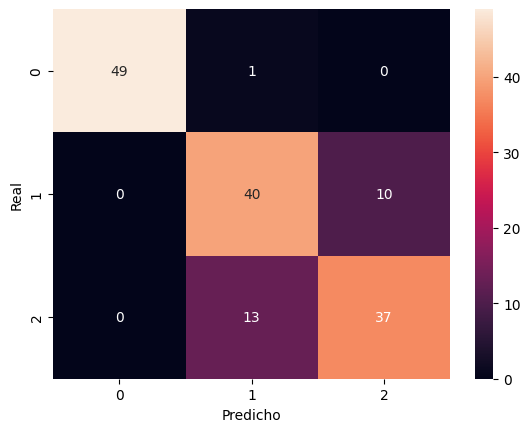

In [32]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_dependiente, y_pred_10)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
#Al tener las variables objetivo más de dos opciones, se uso avarage="macro"
precision_10 = precision_score(y_dependiente, y_pred_10,average="macro")
recall_10 = recall_score(y_dependiente, y_pred_10, average="macro")
f1_10 = f1_score(y_dependiente, y_pred_10, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_10, recall_10,f1_10]})
metricas

,Métricas,Valores
0,Precisión,0.842658
1,Recall,0.840000
2,F1,0.840672


In [16]:
model_KNN_20 = KNeighborsClassifier(n_neighbors =20)
model_KNN_20.fit(X_independientes_tr, y_dependiente)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


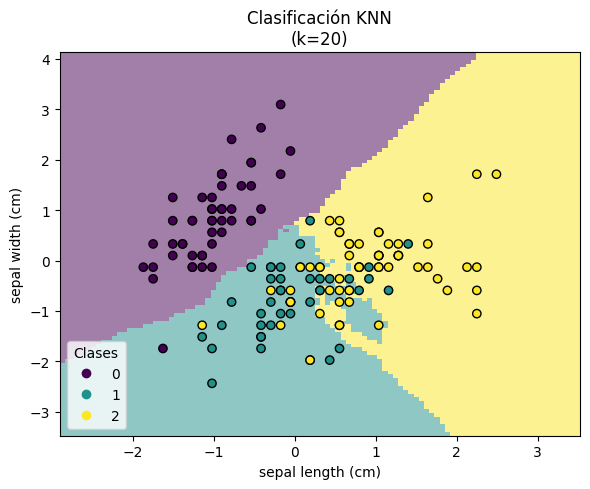

In [31]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

weights = "uniform"

model_KNN_20.set_params(weights=weights).fit(X_independientes_tr, y_dependiente)

disp = DecisionBoundaryDisplay.from_estimator(
    model_KNN_20,
    X_independientes_tr,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel="sepal length (cm)",
    ylabel="sepal width (cm)",
    shading="auto",
    alpha=0.5,
    ax=ax,
)

scatter = disp.ax_.scatter(
    X_independientes_tr[:, 0],
    X_independientes_tr[:, 1],c=y_dependiente, edgecolors="k"
)

disp.ax_.legend(
    scatter.legend_elements()[0],
    y_dependiente.unique(),
    loc="lower left",
    title="Clases",
)

disp.ax_.set_title(
    f"Clasificación KNN\n(k={model_KNN_20.n_neighbors})"
)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_20 = model_KNN_20.predict(X_independientes_tr)
accuracy_20 = accuracy_score(y_dependiente, y_pred_20)
print("El accuracy score que se tiene es %s" %accuracy_20)

El accuracy score que se tiene es 0.7733333333333333


Text(50.722222222222214, 0.5, 'Real')

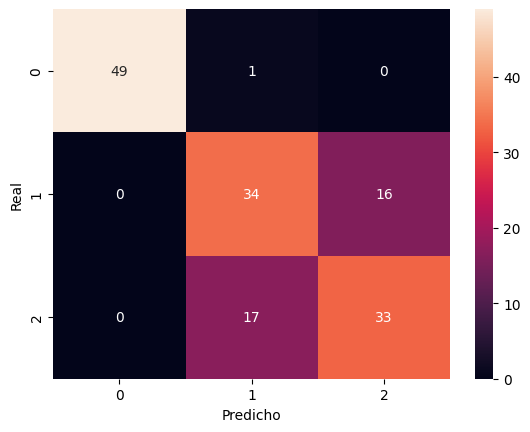

In [30]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_dependiente, y_pred_20)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
#Al tener las variables objetivo más de dos opciones, se uso avarage="macro"
precision_20 = precision_score(y_dependiente, y_pred_20,average="macro")
recall_20 = recall_score(y_dependiente, y_pred_20, average="macro")
f1_20 = f1_score(y_dependiente, y_pred_20, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_20, recall_20,f1_20]})
metricas

,Métricas,Valores
0,Precisión,0.775772
1,Recall,0.773333
2,F1,0.774411


In [21]:
# Encontrar el valor optimo de K
from sklearn.model_selection import cross_val_score
# valores de K que vamos a probar--------------------------------


k_range = range(1, 100)
# inicializar vector de puntuaciones-----------------------------
k_scores = []
# bucle
for k in k_range:
    # ajustar el modelo con k vecinos
    knn = KNeighborsClassifier(n_neighbors=k)
    # obtener puntuaciones de VC
    scores = cross_val_score(knn, X_independientes_tr, y_dependiente,cv = 10, scoring = "accuracy")
    # Guardar puntuaciones en el vector
    k_scores.append(scores.mean())

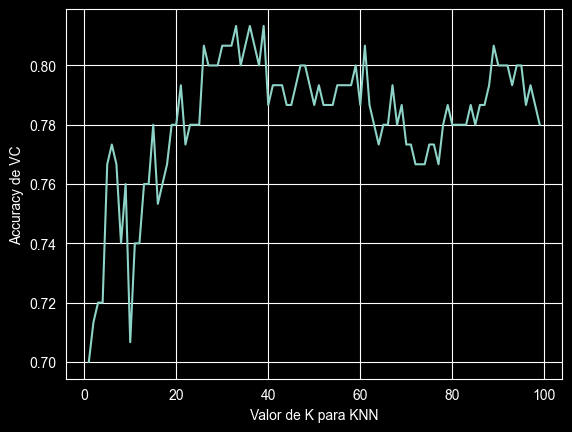

In [22]:
# print(k_scores)
# pintar valores-------------------------------------------------
plt.plot(k_range, k_scores)
plt.xlabel('Valor de K para KNN')
plt.ylabel('Accuracy de VC')
plt.show()

In [23]:
print("El valor de K que maximiza la accuracy es", np.argmax(k_scores) + 1)

El valor de K que maximiza la accuracy es 33


In [24]:
model_KNN_33 = KNeighborsClassifier(n_neighbors =33)
model_KNN_33.fit(X_independientes_tr, y_dependiente)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",33
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


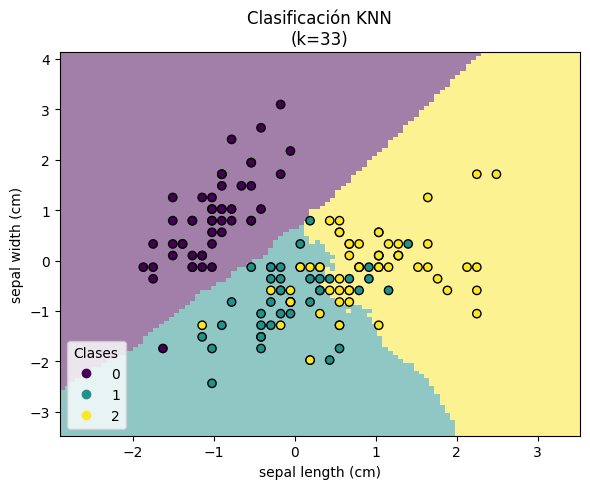

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

weights = "uniform"

model_KNN_33.set_params(weights=weights).fit(X_independientes_tr, y_dependiente)

disp = DecisionBoundaryDisplay.from_estimator(
    model_KNN_33,
    X_independientes_tr,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel="sepal length (cm)",
    ylabel="sepal width (cm)",
    shading="auto",
    alpha=0.5,
    ax=ax,
)

scatter = disp.ax_.scatter(
    X_independientes_tr[:, 0],
    X_independientes_tr[:, 1],c=y_dependiente, edgecolors="k"
)

disp.ax_.legend(
    scatter.legend_elements()[0],
    y_dependiente.unique(),
    loc="lower left",
    title="Clases",
)

disp.ax_.set_title(
    f"Clasificación KNN\n(k={model_KNN_33.n_neighbors})"
)

plt.tight_layout()
plt.show()

In [26]:
#Realizar la predicción para la media de las variables

media = np.mean(X_independientes_tr, axis=0).reshape(1,-1)

prediccion = model_KNN_33.predict(media)
print("La predicción que se tiene para la media de las variables es %s" %prediccion)

La predicción que se tiene para la media de las variables es [1]


In [27]:
proba = model_KNN_33.predict_proba(media)
print("La probabilidad de pertenecer a la clase 0 es %s" %proba[0,0]) 
print("La probabilidad de pertenecer a la clase 1 es %s" %proba[0,1]) 
print("La probabilidad de pertenecer a la clase 2 es %s" %proba[0,2]) 

La probabilidad de pertenecer a la clase 0 es 0.0
La probabilidad de pertenecer a la clase 1 es 0.5757575757575758
La probabilidad de pertenecer a la clase 2 es 0.42424242424242425


In [28]:
proba

array([[0.        , 0.57575758, 0.42424242]])